# Exploratory Data Analysis — Renal Dose Adjustment (Proposal 1)

**Purpose.** Before any modelling, we characterise the data: how much of it is
usable, what the distributions look like, whether eGFR and CrCl genuinely
differ, what the trajectories and slopes look like, how rare a threshold breach
is, and — critically — how strongly the candidate features correlate with the
outcome (the confounding risk named in the proposal).

**Data source switch.** This notebook runs on the *synthetic seed* now, and the
*MIMIC-IV demo* later, by changing one variable. All plots and counts are
computed the same way for both, so the analysis transfers unchanged.

> Synthetic data is clearly labelled as such. Numbers below are illustrative
> until re-run on MIMIC-IV.

**Steps**
1. Load data (synthetic or MIMIC)
2. Data quality & cohort completeness
3. Univariate distributions
4. eGFR vs CrCl — do they diverge?
5. Trajectories and slope distribution
6. Target: how rare is a breach?
7. Feature correlations & the confounding check
8. Summary of findings


In [1]:
# --- setup ---
import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
TEAL, AMBER, RED, GREY = '#0b6b5b', '#b26a00', '#a3231f', '#7c9c95'
FIGDIR = 'figures'; os.makedirs(FIGDIR, exist_ok=True)

# ---------------------------------------------------------------
# DATA SOURCE SWITCH  — flip this to 'mimic' once the demo is set up
# ---------------------------------------------------------------
SOURCE = 'synthetic'          # 'synthetic' | 'mimic'
MIMIC_HOSP_DIR = '../data/mimic-demo/hosp'   # used only when SOURCE='mimic'
DB_PATH = '../../backend/renal.db'           # used only when SOURCE='synthetic'
print('Data source:', SOURCE)


Data source: synthetic


## Step 1 — Load data

The synthetic loader reads the seeded SQLite DB (patients, labs, drugs). The
MIMIC loader reads the demo `hosp` CSVs and derives the same three frames, so
everything downstream is source-agnostic. We standardise on three tables:
`patients`, `labs` (per-measurement eGFR/CrCl), and `drugs` (renal drugs per
patient).

In [2]:
def load_synthetic(db_path):
    con = sqlite3.connect(db_path)
    patients = pd.read_sql('SELECT * FROM patients', con)
    labs = pd.read_sql('SELECT * FROM labs', con, parse_dates=['measured_on'])
    drugs = pd.read_sql('SELECT * FROM drugs', con)
    con.close()
    return patients, labs, drugs

def load_mimic(hosp_dir):
    # Minimal loader: creatinine -> eGFR (CKD-EPI 2021) + prescriptions.
    # Weight (for CrCl) comes from omr; left as NaN if absent.
    import glob
    def find(stem):
        hits = glob.glob(os.path.join(hosp_dir, stem + '.csv*'))
        return hits[0]
    pts = pd.read_csv(find('patients'))
    pts.columns = [c.lower() for c in pts.columns]
    patients = pts.rename(columns={'subject_id':'id','anchor_age':'age',
                                   'gender':'sex'})[['id','age','sex']]
    # creatinine (itemid 50912) from labevents, streamed
    frames = []
    for chunk in pd.read_csv(find('labevents'),
                             usecols=lambda c: c.lower() in
                             {'subject_id','itemid','charttime','valuenum'},
                             chunksize=500000, low_memory=False):
        chunk.columns=[c.lower() for c in chunk.columns]
        frames.append(chunk[chunk['itemid']==50912])
    lab = pd.concat(frames, ignore_index=True).dropna(subset=['valuenum'])
    lab = lab[(lab['valuenum']>0)&(lab['valuenum']<40)]
    lab = lab.merge(patients, left_on='subject_id', right_on='id')
    k = np.where(lab['sex'].str.upper().eq('M'), 0.9, 0.7)
    a = np.where(lab['sex'].str.upper().eq('M'), -0.302, -0.241)
    fem = lab['sex'].str.upper().eq('F')
    r = lab['valuenum']/k
    egfr = (142*np.minimum(r,1)**a*np.maximum(r,1)**-1.2
            *0.9938**lab['age']*np.where(fem,1.012,1.0))
    labs = pd.DataFrame({'patient_id':lab['subject_id'],
                         'measured_on':pd.to_datetime(lab['charttime'],errors='coerce'),
                         'egfr':egfr.round(1), 'crcl':np.nan})
    rx = pd.read_csv(find('prescriptions'),
                     usecols=lambda c: c.lower() in {'subject_id','drug'})
    rx.columns=[c.lower() for c in rx.columns]
    drugs = rx.rename(columns={'subject_id':'patient_id','drug':'ingredient'})
    return patients, labs, drugs

if SOURCE == 'synthetic':
    patients, labs, drugs = load_synthetic(DB_PATH)
else:
    patients, labs, drugs = load_mimic(MIMIC_HOSP_DIR)

print(f'patients: {len(patients)}  |  lab rows: {len(labs)}  |  drug rows: {len(drugs)}')
patients.head()


patients: 24  |  lab rows: 132  |  drug rows: 45


,id,name,age,sex
0,1,Aisha Ahmed,86,F
1,2,Brian Brown,70,F
2,3,Chloe Chen,66,M
3,4,Dev Das,78,F
4,5,Elena Evans,77,F


## Step 2 — Data quality & cohort completeness

A patient is only usable for the *predictive* layer if they have at least two
creatinine readings (so a slope can be fitted). CrCl additionally needs weight.
These counts define the usable cohort and are the first thing an examiner looks
for.

In [3]:
labs_per_patient = labs.groupby('patient_id').size()
n_total = patients['id'].nunique()
n_ge2 = (labs_per_patient >= 2).sum()
n_crcl = labs['crcl'].notna().sum()
crcl_cov = 100*labs['crcl'].notna().mean()

qa = pd.DataFrame({
    'metric': ['Patients total',
               'Patients with >=2 creatinine readings (usable for slope)',
               'Lab rows with CrCl available',
               'CrCl coverage (%)',
               'Median readings per patient'],
    'value':  [n_total, n_ge2, n_crcl, round(crcl_cov,1),
               int(labs_per_patient.median())]
})
print(qa.to_string(index=False))

# missingness table
miss = pd.DataFrame({
    'column': ['egfr','crcl'],
    'missing_%': [round(100*labs['egfr'].isna().mean(),1),
                  round(100*labs['crcl'].isna().mean(),1)]
})
print('\nMissingness:'); print(miss.to_string(index=False))


                                                  metric  value
                                          Patients total   24.0
Patients with >=2 creatinine readings (usable for slope)   24.0
                            Lab rows with CrCl available  132.0
                                       CrCl coverage (%)  100.0
                             Median readings per patient    5.0

Missingness:
column  missing_%
  egfr        0.0
  crcl        0.0


## Step 3 — Univariate distributions

Distribution shape drives modelling choices: skew suggests transformation,
out-of-range values suggest cleaning. We plot the latest eGFR per patient, age,
and renal-drug count.

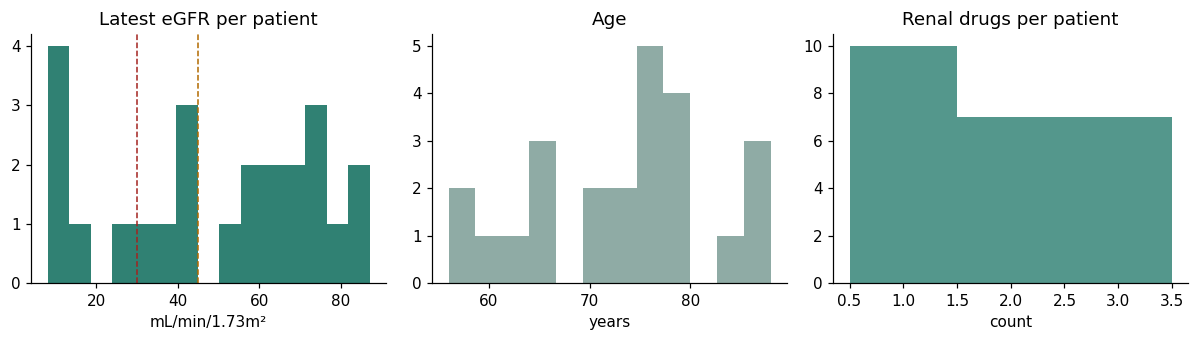

eGFR summary:
count    24.0
mean     48.9
std      26.3
min       8.0
25%      28.7
50%      55.6
75%      71.0
max      87.2


In [4]:
latest = (labs.sort_values('measured_on')
              .groupby('patient_id').tail(1)
              .set_index('patient_id'))
dcount = drugs.groupby('patient_id').size().rename('n_drugs')

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].hist(latest['egfr'], bins=15, color=TEAL, alpha=.85)
ax[0].axvline(45, color=AMBER, ls='--', lw=1); ax[0].axvline(30, color=RED, ls='--', lw=1)
ax[0].set_title('Latest eGFR per patient'); ax[0].set_xlabel('mL/min/1.73m²')

ax[1].hist(patients['age'], bins=12, color=GREY, alpha=.85)
ax[1].set_title('Age'); ax[1].set_xlabel('years')

ax[2].hist(dcount, bins=range(1, int(dcount.max())+2), color=TEAL, alpha=.7, align='left')
ax[2].set_title('Renal drugs per patient'); ax[2].set_xlabel('count')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/03_distributions.png', bbox_inches='tight'); plt.show()
print('eGFR summary:'); print(latest['egfr'].describe().round(1).to_string())


## Step 4 — eGFR vs CrCl: do they diverge?

This is the empirical evidence for evaluating each drug on its **own** metric.
If eGFR and CrCl were interchangeable, every point would sit on the diagonal.
Divergence off the line — driven by body size — is exactly why DOACs, LMWH, and
aminoglycosides are dosed on CrCl, not eGFR.

*(Synthetic note: the seeder derives CrCl from the same creatinine as eGFR, so
some correlation is by construction; on MIMIC the spread will be wider.)*

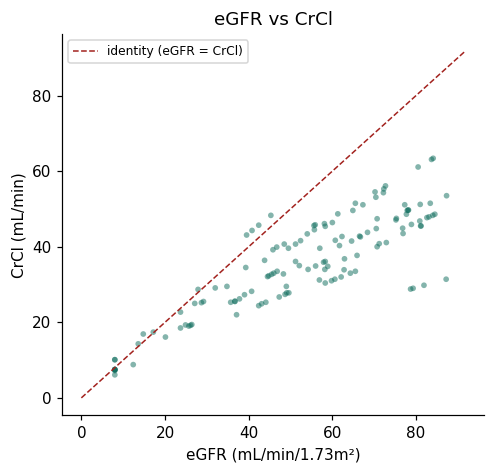

Pearson r(eGFR, CrCl) = 0.852
Rows where eGFR says OK (>=45) but CrCl says caution (<45): 40.2%


In [5]:
pair = labs.dropna(subset=['egfr','crcl'])
if len(pair):
    fig, ax = plt.subplots(figsize=(4.6, 4.4))
    ax.scatter(pair['egfr'], pair['crcl'], s=14, color=TEAL, alpha=.5, edgecolor='none')
    lim = [0, max(pair['egfr'].max(), pair['crcl'].max())*1.05]
    ax.plot(lim, lim, color=RED, ls='--', lw=1, label='identity (eGFR = CrCl)')
    ax.set_xlabel('eGFR (mL/min/1.73m²)'); ax.set_ylabel('CrCl (mL/min)')
    ax.set_title('eGFR vs CrCl'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(f'{FIGDIR}/04_egfr_vs_crcl.png', bbox_inches='tight'); plt.show()
    r = pair['egfr'].corr(pair['crcl'])
    disagree = ((pair['egfr']>=45) & (pair['crcl']<45)).mean()*100
    print(f'Pearson r(eGFR, CrCl) = {r:.3f}')
    print(f'Rows where eGFR says OK (>=45) but CrCl says caution (<45): {disagree:.1f}%')
else:
    print('No CrCl available in this source (expected for MIMIC demo without weight).')


## Step 5 — Trajectories and slope distribution

The predictive layer keys on the *slope* of renal function, not the current
value. A spaghetti plot of a sample of patients shows the shapes; the slope
histogram shows how many are declining fast enough to matter.

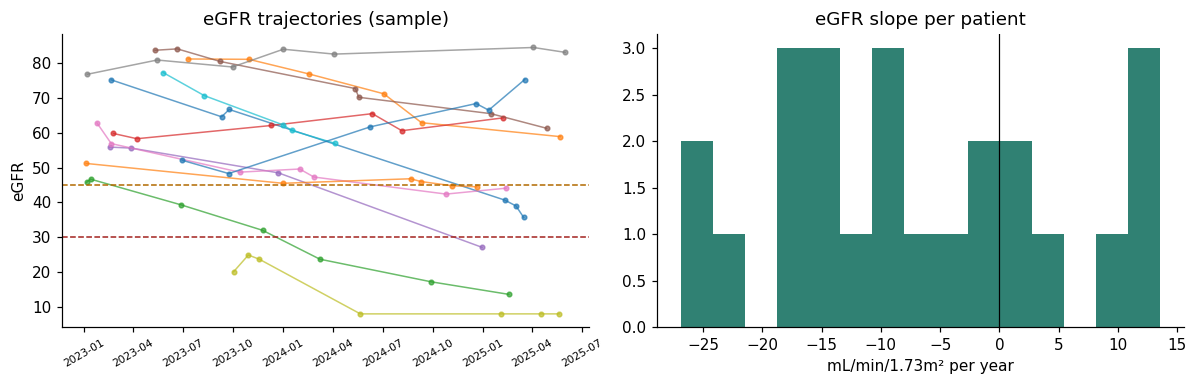

declining patients (slope < -3/yr): 14 of 24


In [6]:
def slope_per_year(g):
    g = g.sort_values('measured_on')
    if len(g) < 2: return np.nan
    yrs = (g['measured_on'] - g['measured_on'].min()).dt.days / 365.25
    if yrs.max() == 0: return np.nan
    return np.polyfit(yrs, g['egfr'], 1)[0]

slopes = labs.groupby('patient_id').apply(slope_per_year).dropna()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
sample = labs['patient_id'].drop_duplicates().head(12)
for pid in sample:
    g = labs[labs['patient_id']==pid].sort_values('measured_on')
    ax[0].plot(g['measured_on'], g['egfr'], marker='o', ms=3, lw=1, alpha=.7)
ax[0].axhline(45, color=AMBER, ls='--', lw=1); ax[0].axhline(30, color=RED, ls='--', lw=1)
ax[0].set_title('eGFR trajectories (sample)'); ax[0].set_ylabel('eGFR')
ax[0].tick_params(axis='x', rotation=30, labelsize=7)

ax[1].hist(slopes, bins=15, color=TEAL, alpha=.85)
ax[1].axvline(0, color='k', lw=.8)
ax[1].set_title('eGFR slope per patient'); ax[1].set_xlabel('mL/min/1.73m² per year')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/05_trajectories.png', bbox_inches='tight'); plt.show()
print(f'declining patients (slope < -3/yr): {(slopes < -3).sum()} of {len(slopes)}')


## Step 6 — Target: how rare is a threshold breach?

We define a simple analysis label: does the patient's latest eGFR sit below 45?
Class balance decides the evaluation metric — a rare positive class means
accuracy is misleading and PR-AUC / recall matter. (The model's true label is
the *forward-looking* horizon crossing; this is the marginal rate.)

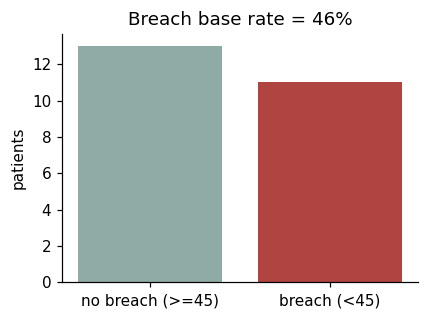

positive (breach) rate: 45.8%  ->  report AUC + PR-AUC, not accuracy


In [7]:
latest2 = latest.copy()
latest2['breach_45'] = (latest2['egfr'] < 45).astype(int)
rate = latest2['breach_45'].mean()
counts = latest2['breach_45'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['no breach (>=45)','breach (<45)'], [counts.get(0,0), counts.get(1,0)],
       color=[GREY, RED], alpha=.85)
ax.set_title(f'Breach base rate = {rate:.0%}'); ax.set_ylabel('patients')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/06_class_balance.png', bbox_inches='tight'); plt.show()
print(f'positive (breach) rate: {rate:.1%}  ->  report AUC + PR-AUC, not accuracy')


## Step 7 — Feature correlations & the confounding check

The proposal's known risk: potassium/outcome is entangled with renal function,
so a model may just relearn eGFR. The renal analogue: does the breach label move
almost entirely with eGFR, leaving little independent signal for drug-count and
trajectory? We check the correlation matrix and, specifically, feature-vs-label
correlations. **Planning this here, not discovering it at evaluation, is the
point.**

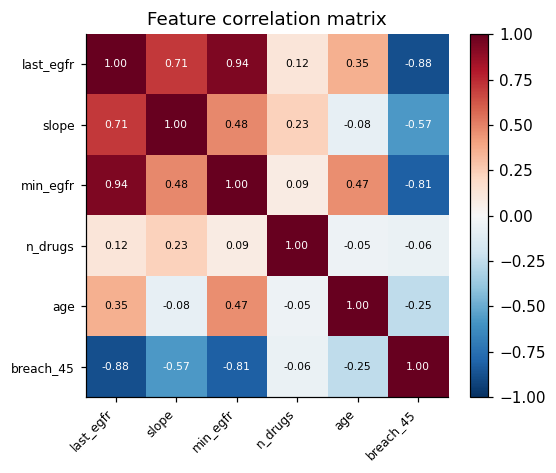

Correlation of each feature with the breach label:
last_egfr   -0.876
min_egfr    -0.813
slope       -0.572
age         -0.252
n_drugs     -0.063

Confounding read: if |corr(last_egfr, breach)| dominates and the others
are near zero, the ML layer must be shown to add signal beyond eGFR
(baseline eGFR-only model vs full model + SHAP).


In [8]:
feat = pd.DataFrame({
    'last_egfr': latest['egfr'],
    'slope': labs.groupby('patient_id').apply(slope_per_year),
    'min_egfr': labs.groupby('patient_id')['egfr'].min(),
    'n_drugs': dcount,
    'age': patients.set_index('id')['age'],
}).dropna()
feat['breach_45'] = (feat['last_egfr'] < 45).astype(int)

corr = feat.corr()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(corr.iloc[i,j])>.5 else 'black')
ax.set_title('Feature correlation matrix'); fig.colorbar(im, fraction=.046)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/07_correlations.png', bbox_inches='tight'); plt.show()

print('Correlation of each feature with the breach label:')
print(corr['breach_45'].drop('breach_45').round(3).sort_values(key=abs, ascending=False).to_string())
print('\nConfounding read: if |corr(last_egfr, breach)| dominates and the others'
      '\nare near zero, the ML layer must be shown to add signal beyond eGFR'
      '\n(baseline eGFR-only model vs full model + SHAP).')


## Step 8 — Summary of findings

*Numbers below are from the **synthetic** seed (24 patients). Re-run with
`SOURCE = 'mimic'` and refresh them before quoting in the dissertation.*

- **Cohort.** 24 patients; all 24 have ≥2 creatinine readings (median 5), so all
  are usable for the trajectory model. CrCl coverage is 100% in synthetic data —
  on MIMIC this drops to whatever OMR weight coverage allows, and becomes the
  limiting factor for CrCl-dosed drugs.
- **Distributions.** Latest eGFR spans 8–87 (mean ≈ 49, sd ≈ 26); no impossible
  values after the creatinine filter. Renal-drug count ranges 1–3.
- **eGFR vs CrCl.** Pearson r ≈ 0.85 — correlated but **not** interchangeable.
  ~40% of readings disagree at the 45 cutoff (eGFR says OK, CrCl says caution).
  This is the empirical justification for evaluating each drug on its own metric.
  *(Synthetic caveat: CrCl is derived from the same creatinine, so real MIMIC
  divergence will differ; re-check there.)*
- **Trajectories.** 14 of 24 patients decline faster than −3 mL/min/1.73m²/yr,
  confirming the slope carries real signal for the anticipation task.
- **Class balance.** Breach base rate ≈ 46% here (synthetic is deliberately
  enriched); on real data breaches are rarer, so evaluate with AUC + PR-AUC and
  recall, never accuracy.
- **Confounding — the key finding.** The breach label correlates −0.88 with
  latest eGFR and −0.81 with min eGFR, but only −0.06 with drug-count and −0.57
  with slope. So renal function dominates, exactly as the proposal's known risk
  warns. The ML layer must therefore be benchmarked against an **eGFR-only
  baseline**, with SHAP demonstrating that slope and drug-count add independent
  signal. Planning this now — not at evaluation — is the point of the EDA.

### Next step
Re-run with `SOURCE = 'mimic'` once the demo `hosp` files are in
`ml/data/mimic-demo/`, refresh these numbers, and paste them into the deck's
Data-analysis slide.
